In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/decades_cleaned.csv')

In [3]:
df.shape

(5279256, 40)

In [4]:
df.head()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,...,key_key_B,key_key_C,key_key_C#,key_key_D,key_key_D#,key_key_E,key_key_F,key_key_F#,key_key_G,key_key_G#
0,100.020943,99.0,99.0,136.0,136.0,1.045157,2.582393,0.816577,1.952720,-653.882874,...,0,0,0,0,0,0,0,0,0,1
1,120.101662,120.0,120.0,101.0,101.0,0.903883,2.234642,0.003441,7.474630,-818.395264,...,0,0,0,0,0,0,0,0,0,0
2,132.114716,133.0,133.0,117.0,117.0,0.963751,2.697139,0.939739,2.026948,-601.399475,...,0,0,0,1,0,0,0,0,0,0
3,95.068558,96.0,96.0,88.0,88.0,1.064906,2.686261,0.687424,3.005937,-683.606689,...,0,0,0,1,0,0,0,0,0,0
4,89.911079,91.0,91.0,120.0,120.0,1.050370,5.002318,0.647487,4.984218,-649.677856,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5279256 entries, 0 to 5279255
Data columns (total 40 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   bpm                                   float64
 1   bpm_histogram_first_peak_bpm_mean     float64
 2   bpm_histogram_first_peak_bpm_median   float64
 3   bpm_histogram_second_peak_bpm_mean    float64
 4   bpm_histogram_second_peak_bpm_median  float64
 5   danceability                          float64
 6   onset_rate                            float64
 7   average_loudness                      float64
 8   dynamic_complexity                    float64
 9   mfcc_zero_mean                        float64
 10  tuning_frequency                      float64
 11  tuning_equal_tempered_deviation       float64
 12  key_scale                             int64  
 13  mood_happy_prob                       float64
 14  mood_aggressive_prob                  float64
 15  mood_happy                

In [6]:
df.isna().sum()

bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                              0
voice_gender                            0
timbre                            

In [7]:
df['decade'].value_counts()

decade
2010    2203515
2000    1357724
1990     782151
2020     436884
1980     252654
1970     142496
1960      78937
1950      24895
Name: count, dtype: int64

Decide to keep Decade target as numeric and not do Label Encoding

Perform train test split using stratified

In [ ]:
from sklearn.model_selection import train_test_split

y = df['decade']
X = df.drop(columns=['decade'])

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
)

# Verify the class distributions
import numpy as np
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training class counts: [     0      0      0 ...      0      0 349507]
Validation class counts: [    0     0     0 ...     0     0 87377]


In [9]:
pd.Series(y_train).value_counts()

decade
2010    1762812
2000    1086179
1990     625721
2020     349507
1980     202123
1970     113997
1960      63149
1950      19916
Name: count, dtype: int64

In [10]:
pd.Series(y_test).value_counts()

decade
2010    440703
2000    271545
1990    156430
2020     87377
1980     50531
1970     28499
1960     15788
1950      4979
Name: count, dtype: int64

In [11]:
y_train.info()

<class 'pandas.Series'>
Index: 4223404 entries, 2968345 to 3711804
Series name: decade
Non-Null Count    Dtype
--------------    -----
4223404 non-null  int64
dtypes: int64(1)
memory usage: 64.4 MB


In [12]:
train_df = pd.concat([X_train, y_train], axis=1)

In [13]:
y_test.info()

<class 'pandas.Series'>
Index: 1055852 entries, 697899 to 1950268
Series name: decade
Non-Null Count    Dtype
--------------    -----
1055852 non-null  int64
dtypes: int64(1)
memory usage: 16.1 MB


In [14]:
train_df.isna().sum()

bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                              0
voice_gender                            0
timbre                            

Correlation Matrix

In [15]:
train_df.corr()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,...,key_key_C,key_key_C#,key_key_D,key_key_D#,key_key_E,key_key_F,key_key_F#,key_key_G,key_key_G#,decade
bpm,1.000000,0.979241,0.979241,0.593608,0.593608,-0.076721,-0.038624,-0.045382,0.002352,0.020827,...,0.001296,-0.000503,0.009249,-0.002513,0.006718,-0.010335,0.000068,0.006855,-0.001099,-0.017786
bpm_histogram_first_peak_bpm_mean,0.979241,1.000000,1.000000,0.579279,0.579279,-0.083065,-0.046342,-0.053104,0.008102,0.014522,...,0.001390,-0.000515,0.008985,-0.001933,0.006328,-0.010428,0.000330,0.006865,-0.000831,-0.017052
bpm_histogram_first_peak_bpm_median,0.979241,1.000000,1.000000,0.579279,0.579279,-0.083065,-0.046342,-0.053104,0.008102,0.014522,...,0.001390,-0.000515,0.008985,-0.001933,0.006328,-0.010428,0.000330,0.006865,-0.000831,-0.017052
bpm_histogram_second_peak_bpm_mean,0.593608,0.579279,0.579279,1.000000,1.000000,-0.088146,-0.045964,-0.045749,0.005790,0.010361,...,0.000987,-0.000808,0.007627,-0.002331,0.006296,-0.007599,0.000201,0.005987,-0.001150,-0.000855
bpm_histogram_second_peak_bpm_median,0.593608,0.579279,0.579279,1.000000,1.000000,-0.088146,-0.045964,-0.045749,0.005790,0.010361,...,0.000987,-0.000808,0.007627,-0.002331,0.006296,-0.007599,0.000201,0.005987,-0.001150,-0.000855
danceability,-0.076721,-0.083065,-0.083065,-0.088146,-0.088146,1.000000,0.620234,0.518177,-0.309105,0.287209,...,-0.024335,0.007877,-0.023384,-0.015347,-0.027738,0.031284,-0.012732,-0.041365,0.011403,0.046801
onset_rate,-0.038624,-0.046342,-0.046342,-0.045964,-0.045964,0.620234,1.000000,0.439044,-0.267592,0.283594,...,-0.022802,-0.001221,-0.022366,-0.016755,-0.027836,0.027743,-0.015391,-0.026817,0.005805,-0.015683
average_loudness,-0.045382,-0.053104,-0.053104,-0.045749,-0.045749,0.518177,0.439044,1.000000,-0.662541,0.697149,...,-0.019761,-0.000477,-0.003712,-0.029612,0.002992,0.007173,-0.013420,-0.027922,-0.003714,0.148422
dynamic_complexity,0.002352,0.008102,0.008102,0.005790,0.005790,-0.309105,-0.267592,-0.662541,1.000000,-0.747812,...,0.010652,-0.002894,-0.006791,0.018552,-0.008548,-0.004712,0.010107,0.020418,0.001496,-0.103780
mfcc_zero_mean,0.020827,0.014522,0.014522,0.010361,0.010361,0.287209,0.283594,0.697149,-0.747812,1.000000,...,-0.019623,0.000410,0.015143,-0.029078,0.014839,-0.004637,-0.012999,-0.024928,-0.009336,0.088484


Define function to check correlated features above 0.8 threshold

In [16]:
def correlation(dataset, threshold):
    col_corr= set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [17]:
corr_features = correlation(train_df, 0.9)

len(set(corr_features))

4

In [18]:
corr_features

{'bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_median',
 'decade'}

Drop the correlated features except decade

In [19]:
X_train.drop(['bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_median'], axis = 1, inplace = True)

In [20]:
X_train.isna().sum()

bpm                                   0
bpm_histogram_second_peak_bpm_mean    0
danceability                          0
onset_rate                            0
average_loudness                      0
dynamic_complexity                    0
mfcc_zero_mean                        0
tuning_frequency                      0
tuning_equal_tempered_deviation       0
key_scale                             0
mood_happy_prob                       0
mood_aggressive_prob                  0
mood_happy                            0
mood_sad                              0
mood_relaxed                          0
mood_aggressive                       0
mood_acoustic                         0
mood_electronic                       0
mood_party                            0
voice_gender                          0
timbre                                0
tonal_atonal                          0
voice_instrumental                    0
release_year                          0
key_key_A                             0


In [21]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4223404 entries, 2968345 to 3711804
Data columns (total 36 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   bpm                                 float64
 1   bpm_histogram_second_peak_bpm_mean  float64
 2   danceability                        float64
 3   onset_rate                          float64
 4   average_loudness                    float64
 5   dynamic_complexity                  float64
 6   mfcc_zero_mean                      float64
 7   tuning_frequency                    float64
 8   tuning_equal_tempered_deviation     float64
 9   key_scale                           int64  
 10  mood_happy_prob                     float64
 11  mood_aggressive_prob                float64
 12  mood_happy                          int64  
 13  mood_sad                            int64  
 14  mood_relaxed                        int64  
 15  mood_aggressive                     int64  
 16  mood_acous

Next observe Mutual Information Gain, examine mutual info between each feature and decade

In [22]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train, y_train, random_state = 42)
mutual_info

KeyboardInterrupt: 

In [ ]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending = False)

release_year                          1.567602
mood_relaxed                          0.173161
mood_electronic                       0.158755
voice_gender                          0.151025
key_scale                             0.147963
timbre                                0.140644
voice_instrumental                    0.125609
tonal_atonal                          0.118144
mood_acoustic                         0.097847
tuning_frequency                      0.092941
mood_party                            0.083371
mood_sad                              0.080012
mood_happy                            0.059710
mood_aggressive                       0.044882
bpm                                   0.037275
tuning_equal_tempered_deviation       0.025665
average_loudness                      0.021656
dynamic_complexity                    0.015849
mfcc_zero_mean                        0.015086
key_key_A                             0.013666
key_key_A#                            0.013260
key_key_F    

Looks like the key columns are more uninformative

No columns I need to drop

Make sure to drop release_year column since captured by Decade column

In [23]:
X_train.drop(['release_year'], axis = 1, inplace = True)

Make sure X_test has same columns as X_train

In [24]:
columns_to_drop_from_X_test = list(X_test.columns.difference(X_train.columns))


In [25]:

X_test.drop(columns = columns_to_drop_from_X_test, inplace = True)

In [26]:
X_train.shape

(4223404, 35)

In [27]:
X_test.shape

(1055852, 35)

View distribution of each feature

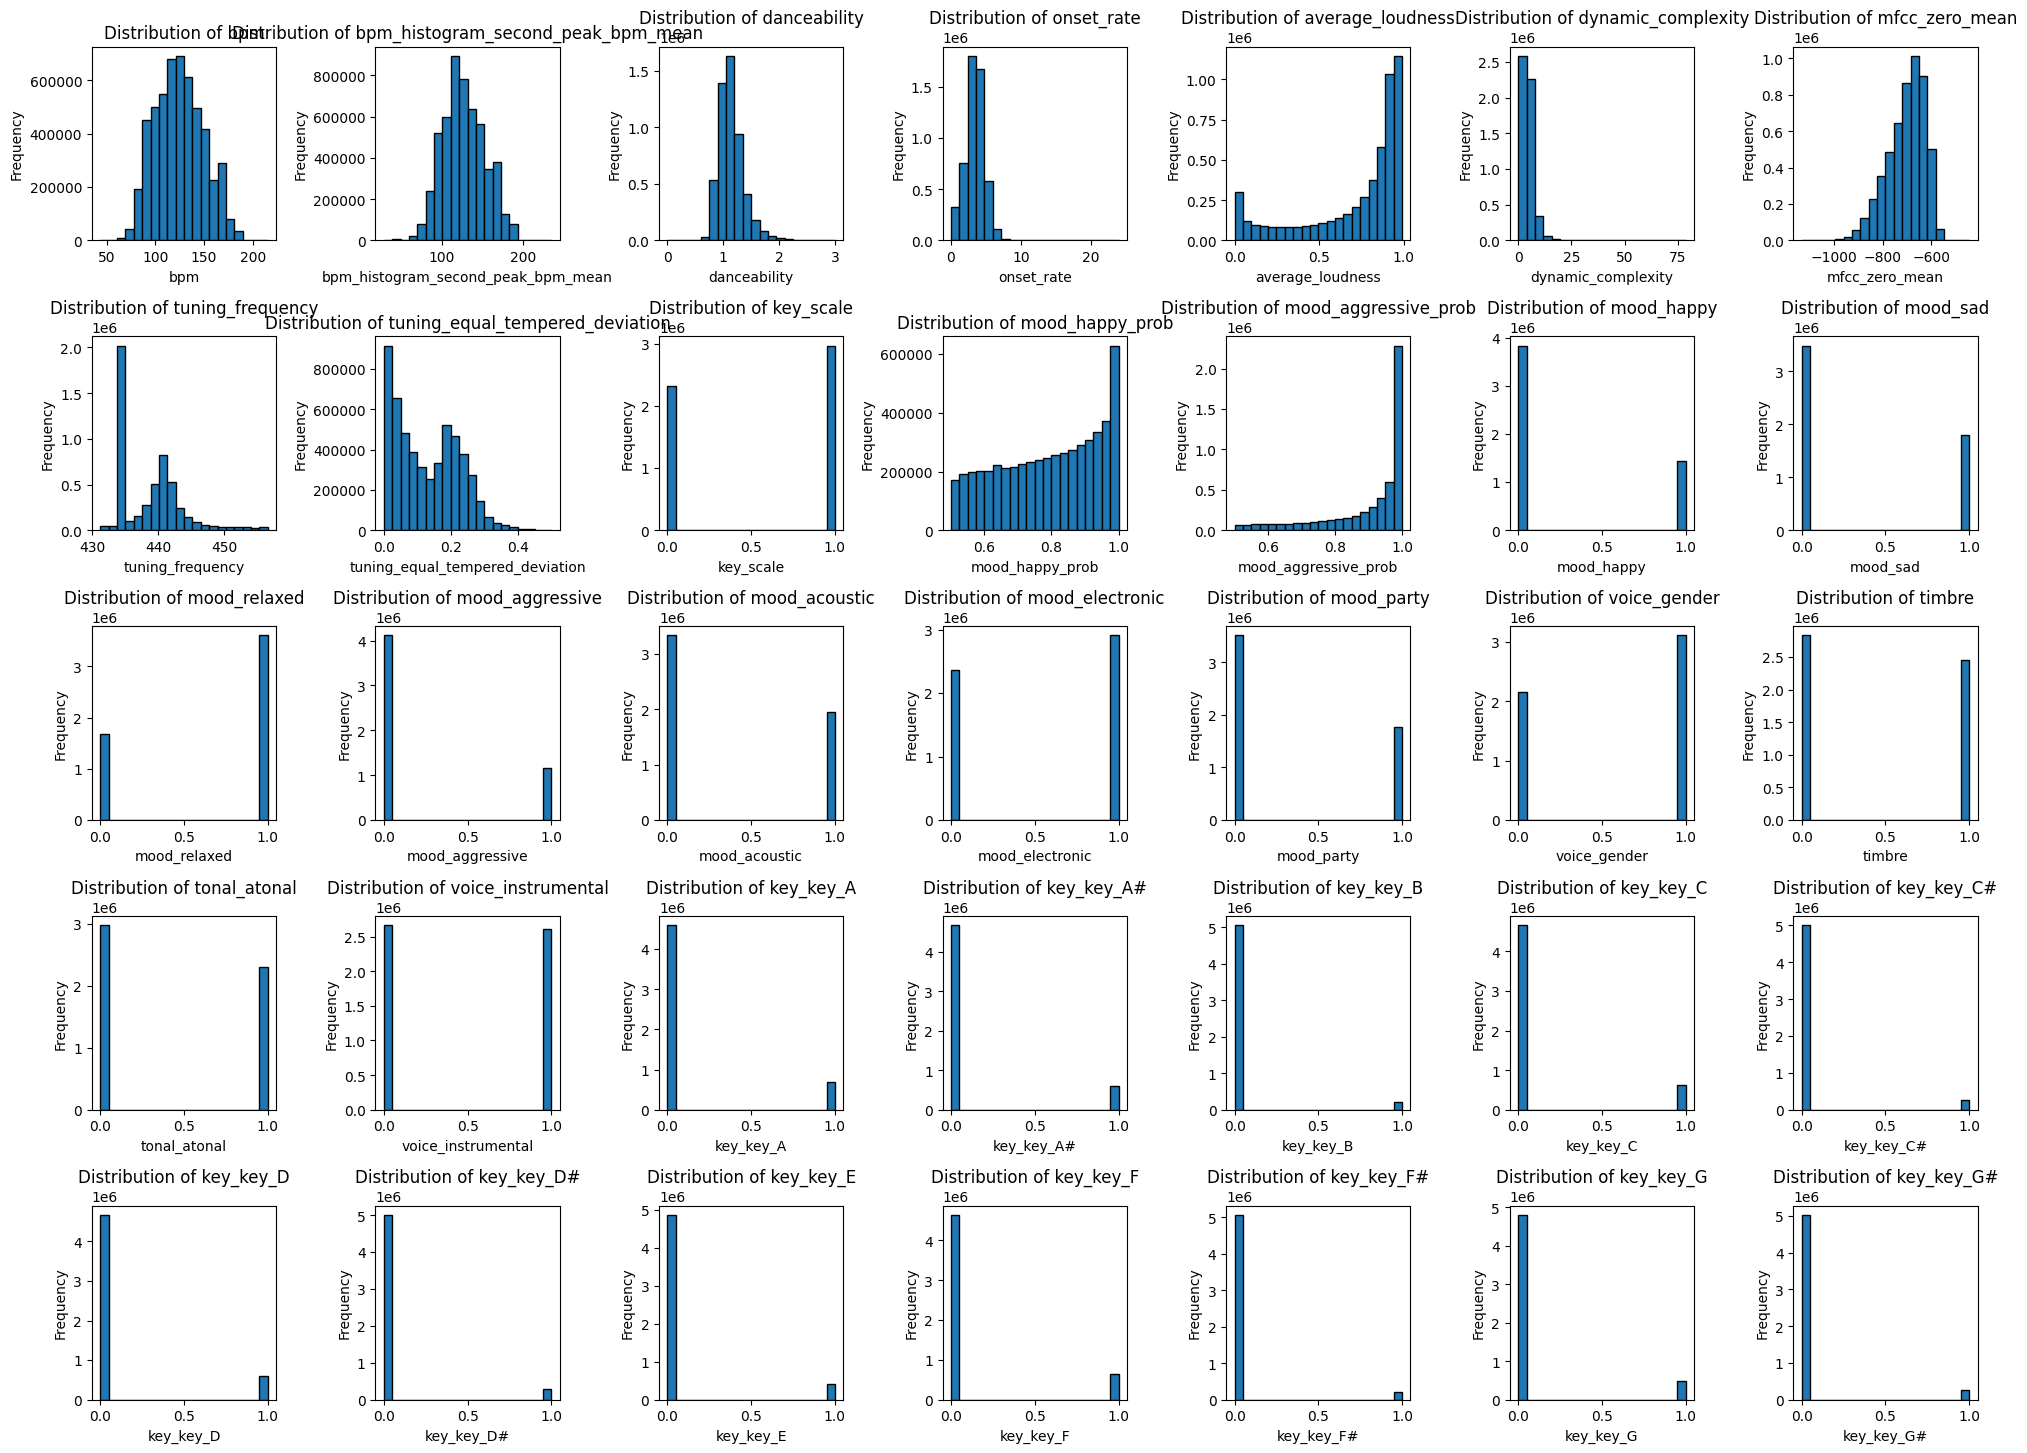

In [28]:
num_cols = len(X_train.columns)
n_cols = 7
n_rows = 7

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Decide how to scale features:

Leave unscaled
* average_loudness - since using tree based models predominantly


Standard scaling
* bpm
* second peak bpm mean
* dancebility
* mfcc_zero_mean
* tuning_frequency - spike is normal frequency

Log transform + standard scaling
* onset_rate
* dynamic complexity
* tuning_equal_tempered_deviation

Min max scaling
* mood happy prob
* mood aggressive prob


Apply Min Max Scaling

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

cols_to_scale = ['mood_happy_prob', 'mood_aggressive_prob']

scaled_X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

scaled_X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [32]:
scaled_X_train.info()

<class 'pandas.DataFrame'>
Index: 2860386 entries, 601385 to 2189456
Data columns (total 36 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   bpm                                   float64
 1   bpm_histogram_second_peak_bpm_mean    float64
 2   bpm_histogram_second_peak_bpm_median  float64
 3   danceability                          float64
 4   onset_rate                            float64
 5   average_loudness                      float64
 6   dynamic_complexity                    float64
 7   mfcc_zero_mean                        float64
 8   tuning_frequency                      float64
 9   tuning_equal_tempered_deviation       float64
 10  key_scale                             int64  
 11  mood_happy_prob                       float64
 12  mood_aggressive_prob                  float64
 13  mood_happy                            int64  
 14  mood_sad                              int64  
 15  mood_relaxed              

Apply Log + Standard Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_for_log = ['onset_rate', 'dynamic_complexity', 'tuning_equal_tempered_deviation']

scaled_X_train[cols_for_log] = np.log1p(X_train[cols_for_log])
scaled_X_test[cols_for_log] = np.log1p(X_test[cols_for_log])

cols_to_scale = ['bpm', 'bpm_histogram_second_peak_bpm_mean', 'danceability', 'mfcc_zero_mean', 'tuning_frequency', 'onset_rate', 'dynamic_complexity', 'tuning_equal_tempered_deviation']

scaled_X_train[cols_to_scale] = scaler.fit_transform(scaled_X_train[cols_to_scale])

scaled_X_test[cols_to_scale] = scaler.transform(scaled_X_test[cols_to_scale])

Convert to DataFrame

In [31]:
scaled_X_train = pd.DataFrame(scaled_X_train, columns = X_train.columns)
scaled_X_test = pd.DataFrame(scaled_X_test, columns = X_test.columns)

View scaled feature distributions

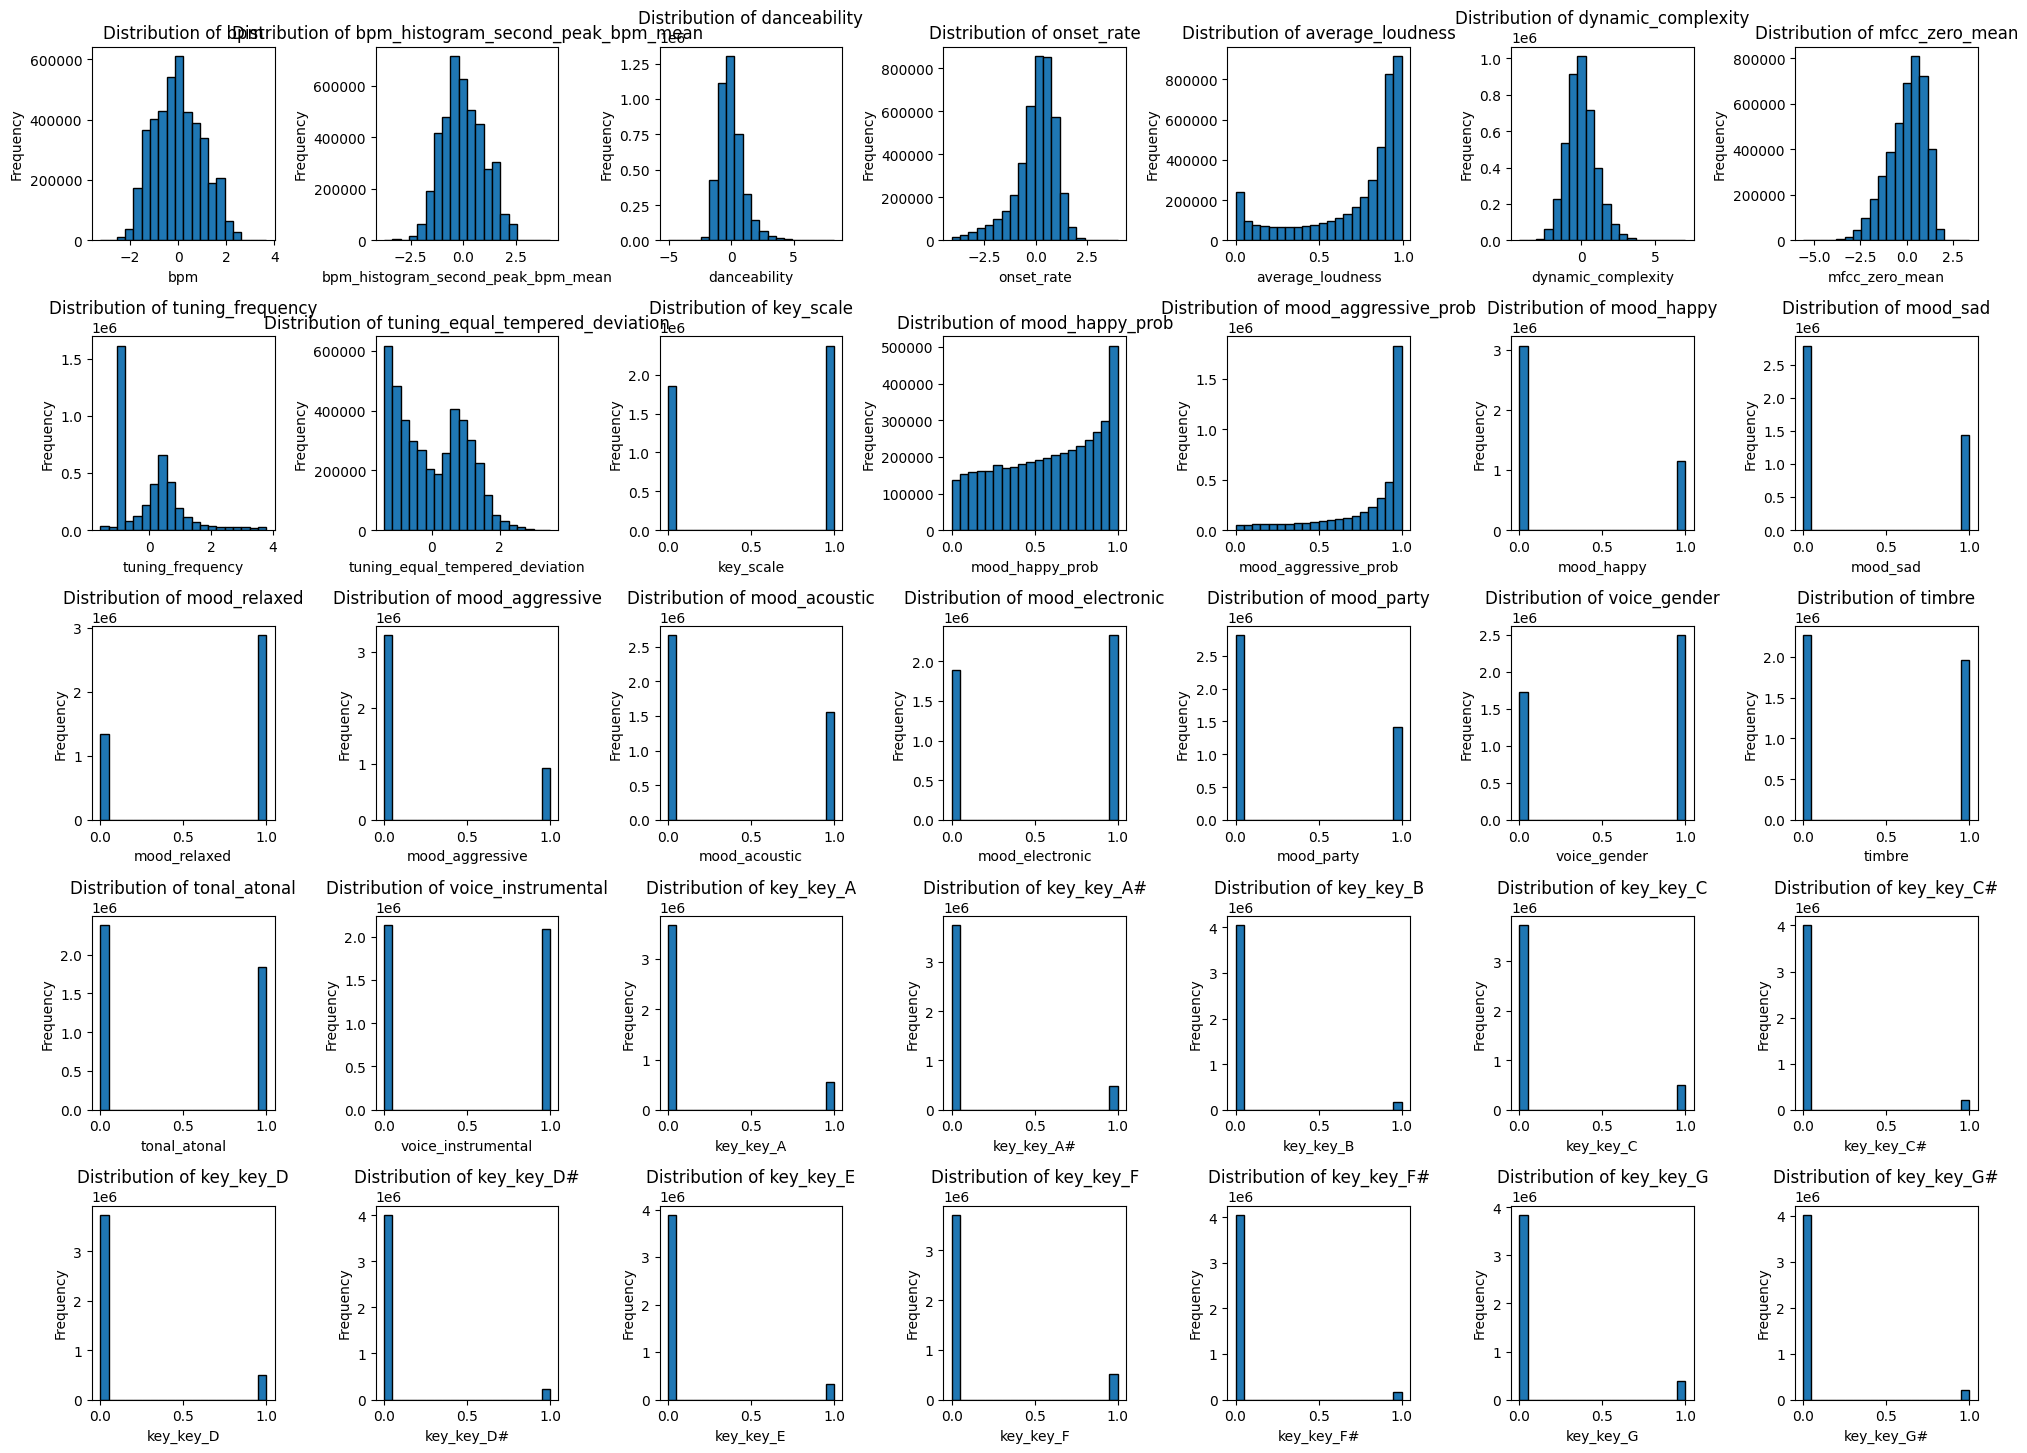

In [32]:
num_cols = len(scaled_X_train.columns)
n_cols = 7
n_rows = 7

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(scaled_X_train.columns):
    axes[i].hist(scaled_X_train[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Output the scaled data to csv

In [33]:
scaled_X_train.to_csv('data/decade_scaled_X_train.csv', index = False)
scaled_X_test.to_csv('data/decade_scaled_X_test.csv', index = False)
y_train.to_csv('data/decade_y_train.csv', index = False)
y_test.to_csv('data/decade_y_test.csv', index = False)